## Data Preprocessing 

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [254]:
electricity_access_df = pd.read_csv("data/raw/1.AccessToElectricityAPI_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63.csv", skiprows=4)
gdp_df = pd.read_csv("data/raw/2.GDPAPI_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv", skiprows=4)
urban_population_df = pd.read_csv("data/raw/3.UrbanAPI_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608.csv", skiprows=4)
rural_population_df = pd.read_csv("data/raw/4.RuralAPI_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502.csv", skiprows=4)
population_density_df = pd.read_csv("data/raw/5.PopulationDensityAPI_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv", skiprows=4)
total_population_df = pd.read_csv("data/raw/6.TotalPopulationAPI_SP.POP.TOTL_DS2_en_csv_v2_7/API_SP.POP.TOTL_DS2_en_csv_v2_7.csv", skiprows=4)
renewable_energy_df = pd.read_csv("data/raw/7.RenewableEnergyAPI_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409.csv", skiprows=4)
government_effectiveness_df = pd.read_csv("data/raw/8.GovernmentEffectivenessAPI_GE.EST_DS2_en_csv_v2_2683/API_GE.EST_DS2_en_csv_v2_2683.csv", skiprows=4)


In [255]:
# Drop unwanted "Unnamed" columns
electricity_access_df = electricity_access_df.loc[:, ~electricity_access_df.columns.str.contains("Unnamed")]
gdp_df = gdp_df.loc[:, ~gdp_df.columns.str.contains("Unnamed")]
urban_population_df = urban_population_df.loc[:, ~urban_population_df.columns.str.contains("Unnamed")]
rural_population_df = rural_population_df.loc[:, ~rural_population_df.columns.str.contains("Unnamed")]
population_density_df = population_density_df.loc[:, ~population_density_df.columns.str.contains("Unnamed")]
total_population_df = total_population_df.loc[:, ~total_population_df.columns.str.contains("Unnamed")]
renewable_energy_df = renewable_energy_df.loc[:, ~renewable_energy_df.columns.str.contains("Unnamed")]
government_effectiveness_df = government_effectiveness_df.loc[:, ~government_effectiveness_df.columns.str.contains("Unnamed")]

In [256]:
# Identify and remove non-country entries
non_countries = [
    "World", "High income", "Low income", "Middle income", "Lower middle income", "Upper middle income",
    "Low & middle income", "Early-demographic dividend", "Late-demographic dividend", "Post-demographic dividend",
    "Pre-demographic dividend", "Europe & Central Asia", "Sub-Saharan Africa", "Latin America & Caribbean",
    "Arab World", "North America", "South Asia", "OECD members", "Small states", "Other small states",
    "Pacific island small states", "Euro area", "European Union", "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)", "IBRD only", "IDA total", "IDA & IBRD total", "IDA blend", "IDA only",
    "East Asia & Pacific", "East Asia & Pacific (IDA & IBRD countries)", "East Asia & Pacific (excluding high income)",
    "Europe & Central Asia (IDA & IBRD countries)", "Europe & Central Asia (excluding high income)",
    "Latin America & Caribbean (excluding high income)", "Latin America & the Caribbean (IDA & IBRD countries)",
    "Middle East, North Africa, Afghanistan & Pakistan", 
    "Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",
    "Middle East, North Africa, Afghanistan & Pakistan (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)", "Sub-Saharan Africa (excluding high income)",
    "Africa Eastern and Southern", "Africa Western and Central", "Caribbean small states", 
    "Central Europe and the Baltics"
]

# Filter out non-country entries from each dataset
electricity_access_df = electricity_access_df[~electricity_access_df["Country Name"].isin(non_countries)]
gdp_df = gdp_df[~gdp_df["Country Name"].isin(non_countries)]
urban_population_df = urban_population_df[~urban_population_df["Country Name"].isin(non_countries)]
rural_population_df = rural_population_df[~rural_population_df["Country Name"].isin(non_countries)]
population_density_df = population_density_df[~population_density_df["Country Name"].isin(non_countries)]
total_population_df = total_population_df[~total_population_df["Country Name"].isin(non_countries)]
renewable_energy_df = renewable_energy_df[~renewable_energy_df["Country Name"].isin(non_countries)]
government_effectiveness_df = government_effectiveness_df[~government_effectiveness_df["Country Name"].isin(non_countries)]

In [257]:
# Inspect columns
print(electricity_access_df.columns)
print(gdp_df.columns)
print(urban_population_df.columns)
print(rural_population_df.columns)
print(population_density_df.columns)
print(total_population_df.columns)
print(renewable_energy_df.columns)
print(government_effectiveness_df.columns)

# Keep only necessary columns: Country Name, Country Code, and all years (1960 onwards)
# Drop Indicator Name and Indicator Code
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in electricity_access_df.columns if col.isdigit()]
electricity_access_df = electricity_access_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in urban_population_df.columns if col.isdigit()]
urban_population_df = urban_population_df[cols_to_keep]                     
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in rural_population_df.columns if col.isdigit()]
rural_population_df = rural_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in population_density_df.columns if col.isdigit()]
population_density_df = population_density_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in total_population_df.columns if col.isdigit()]
total_population_df = total_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in renewable_energy_df.columns if col.isdigit()]
renewable_energy_df = renewable_energy_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in government_effectiveness_df.columns if col.isdigit()]
government_effectiveness_df = government_effectiveness_df[cols_to_keep] 

# Rename columns for convenience
electricity_access_df.columns = electricity_access_df.columns.str.strip()
electricity_access_df = electricity_access_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
gdp_df.columns = gdp_df.columns.str.strip()
gdp_df = gdp_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
urban_population_df.columns = urban_population_df.columns.str.strip()
urban_population_df = urban_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
rural_population_df.columns = rural_population_df.columns.str.strip()
rural_population_df = rural_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
population_density_df.columns = population_density_df.columns.str.strip()
population_density_df = population_density_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
total_population_df.columns = total_population_df.columns.str.strip()
total_population_df = total_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
renewable_energy_df.columns = renewable_energy_df.columns.str.strip()
renewable_energy_df = renewable_energy_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
government_effectiveness_df.columns = government_effectiveness_df.columns.str.strip()
government_effectiveness_df = government_effectiveness_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})   


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='str')
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1

In [258]:
# Reshape electricity access dataset from wide to long format
electricity_access_df_long = electricity_access_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="electricity_access"
)
gdp_df_long = gdp_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="gdp_per_capita"
)
urban_population_df_long = urban_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="urban_population_percent"
)
rural_population_df_long = rural_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="rural_population_percent"
)
population_density_df_long = population_density_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="population_density"
)
total_population_df_long = total_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="total_population"
)
renewable_energy_df_long = renewable_energy_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="renewable_energy_percent"
)
government_effectiveness_df_long = government_effectiveness_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="government_effectiveness"
)
# Convert year column to integer
electricity_access_df_long["year"] = electricity_access_df_long["year"].astype(int)
gdp_df_long["year"] = gdp_df_long["year"].astype(int)
urban_population_df_long["year"] = urban_population_df_long["year"].astype(int)
rural_population_df_long["year"] = rural_population_df_long["year"].astype(int)
population_density_df_long["year"] = population_density_df_long["year"].astype(int)
total_population_df_long["year"] = total_population_df_long["year"].astype(int)
renewable_energy_df_long["year"] = renewable_energy_df_long["year"].astype(int)
government_effectiveness_df_long["year"] = government_effectiveness_df_long["year"].astype(int)

# Convert electricity_access to numeric (some cells might be empty strings)
electricity_access_df_long['electricity_access'] = pd.to_numeric(electricity_access_df_long['electricity_access'], errors='coerce')
gdp_df_long['gdp_per_capita'] = pd.to_numeric(gdp_df_long['gdp_per_capita'], errors='coerce')
urban_population_df_long['urban_population_percent'] = pd.to_numeric(urban_population_df_long['urban_population_percent'], errors='coerce')
rural_population_df_long['rural_population_percent'] = pd.to_numeric(rural_population_df_long['rural_population_percent'], errors='coerce')     
population_density_df_long['population_density'] = pd.to_numeric(population_density_df_long['population_density'], errors='coerce')
total_population_df_long['total_population'] = pd.to_numeric(total_population_df_long['total_population'], errors='coerce')
renewable_energy_df_long['renewable_energy_percent'] = pd.to_numeric(renewable_energy_df_long['renewable_energy_percent'], errors='coerce')
government_effectiveness_df_long['government_effectiveness'] = pd.to_numeric(government_effectiveness_df_long['government_effectiveness'], errors='coerce')


# Sort by country and year
electricity_access_df_long = electricity_access_df_long.sort_values(['country', 'year']).reset_index(drop=True)
gdp_df_long = gdp_df_long.sort_values(['country', 'year']).reset_index(drop=True)
urban_population_df_long = urban_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
rural_population_df_long = rural_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
population_density_df_long = population_density_df_long.sort_values(['country', 'year']).reset_index(drop=True)
total_population_df_long = total_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long.sort_values(['country', 'year']).reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long.sort_values(['country', 'year']).reset_index(drop=True)


In [259]:
# Keep only 1990 and later
electricity_access_df_long = electricity_access_df_long[electricity_access_df_long['year'] >= 1990].reset_index(drop=True)
gdp_df_long = gdp_df_long[gdp_df_long['year'] >= 1990].reset_index(drop=True)
urban_population_df_long = urban_population_df_long[urban_population_df_long['year'] >= 1990].reset_index(drop=True)
rural_population_df_long = rural_population_df_long[rural_population_df_long['year'] >= 1990].reset_index(drop=True)
population_density_df_long = population_density_df_long[population_density_df_long['year'] >= 1990].reset_index(drop=True)
total_population_df_long = total_population_df_long[total_population_df_long['year'] >= 1990].reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long[renewable_energy_df_long['year'] >= 1990].reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long[government_effectiveness_df_long['year'] >= 1990].reset_index(drop=True)


In [260]:

print(electricity_access_df_long.head(10))
print(gdp_df_long.head(10))
print(urban_population_df_long.head(10))
print(rural_population_df_long.head(10))
print(population_density_df_long.head(10))
print(total_population_df_long.head(10))
print(renewable_energy_df_long.head(10))
print(government_effectiveness_df_long.head(10))


       country country_code  year  electricity_access
0  Afghanistan          AFG  1990                 NaN
1  Afghanistan          AFG  1991                 NaN
2  Afghanistan          AFG  1992                 NaN
3  Afghanistan          AFG  1993                 NaN
4  Afghanistan          AFG  1994                 NaN
5  Afghanistan          AFG  1995                 NaN
6  Afghanistan          AFG  1996                 NaN
7  Afghanistan          AFG  1997                 NaN
8  Afghanistan          AFG  1998                 NaN
9  Afghanistan          AFG  1999                 NaN
       country country_code  year  gdp_per_capita
0  Afghanistan          AFG  1990             NaN
1  Afghanistan          AFG  1991             NaN
2  Afghanistan          AFG  1992             NaN
3  Afghanistan          AFG  1993             NaN
4  Afghanistan          AFG  1994             NaN
5  Afghanistan          AFG  1995             NaN
6  Afghanistan          AFG  1996             NaN
7  Afg

In [261]:
# For ALL variables, use per-country linear interpolation with bidirectional filling
# This is more accurate than global median as it preserves country-specific patterns

# Electricity access
electricity_access_df_long = electricity_access_df_long.sort_values(['country', 'year'])
electricity_access_df_long['electricity_access'] = (
    electricity_access_df_long.groupby('country')['electricity_access']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# GDP per capita
gdp_df_long = gdp_df_long.sort_values(['country', 'year'])
gdp_df_long['gdp_per_capita'] = (
    gdp_df_long.groupby('country')['gdp_per_capita']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Urban population
urban_population_df_long = urban_population_df_long.sort_values(['country', 'year'])
urban_population_df_long['urban_population_percent'] = (
    urban_population_df_long.groupby('country')['urban_population_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Rural population
rural_population_df_long = rural_population_df_long.sort_values(['country', 'year'])
rural_population_df_long['rural_population_percent'] = (
    rural_population_df_long.groupby('country')['rural_population_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Population density
population_density_df_long = population_density_df_long.sort_values(['country', 'year'])
population_density_df_long['population_density'] = (
    population_density_df_long.groupby('country')['population_density']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Total population
total_population_df_long = total_population_df_long.sort_values(['country', 'year'])
total_population_df_long['total_population'] = (
    total_population_df_long.groupby('country')['total_population']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Renewable energy
renewable_energy_df_long = renewable_energy_df_long.sort_values(['country', 'year'])
renewable_energy_df_long['renewable_energy_percent'] = (
    renewable_energy_df_long.groupby('country')['renewable_energy_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Government effectiveness
government_effectiveness_df_long = government_effectiveness_df_long.sort_values(['country', 'year'])
government_effectiveness_df_long['government_effectiveness'] = (
    government_effectiveness_df_long.groupby('country')['government_effectiveness']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

In [262]:
# Save cleaned and reshaped datasets to new CSV files for future use
electricity_access_df_long.to_csv("data/processed/electricity_access_long.csv", index=False)
gdp_df_long.to_csv("data/processed/gdp_long.csv", index=False)
urban_population_df_long.to_csv("data/processed/urban_population_long.csv", index=False)
rural_population_df_long.to_csv("data/processed/rural_population_long.csv", index=False)
population_density_df_long.to_csv("data/processed/population_density_long.csv", index=False)
total_population_df_long.to_csv("data/processed/total_population_long.csv", index=False)
renewable_energy_df_long.to_csv("data/processed/renewable_energy_long.csv", index=False)
government_effectiveness_df_long.to_csv("data/processed/government_effectiveness_long.csv", index=False)


In [263]:
electricity_access_df_long.head()

,country,country_code,year,electricity_access
0,Afghanistan,AFG,1990,4.4
1,Afghanistan,AFG,1991,4.4
2,Afghanistan,AFG,1992,4.4
3,Afghanistan,AFG,1993,4.4
4,Afghanistan,AFG,1994,4.4


In [264]:
# Merge all datasets into a single dataframe for modeling

merged_df = electricity_access_df_long[['country', 'country_code', 'year', 'electricity_access']]
merged_df = merged_df.merge(gdp_df_long[['country', 'year', 'gdp_per_capita']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(urban_population_df_long[['country', 'year', 'urban_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(rural_population_df_long[['country', 'year', 'rural_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(population_density_df_long[['country', 'year', 'population_density']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(total_population_df_long[['country', 'year', 'total_population']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(renewable_energy_df_long[['country', 'year', 'renewable_energy_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(government_effectiveness_df_long[['country', 'year', 'government_effectiveness']], on=['country', 'year'], how='left')

# Save the final merged dataset to a CSV file for modeling
merged_df.to_csv('data/processed/merged_dataset.csv', index=False)

In [265]:
# Load the merged dataset
df = pd.read_csv('data/processed/merged_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of countries: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

# Display first 10 rows
df.head(10)

Dataset shape: (7700, 11)
Number of countries: 220
Year range: 1990 to 2024


,country,country_code,year,electricity_access,gdp_per_capita,urban_population_percent,rural_population_percent,population_density,total_population,renewable_energy_percent,government_effectiveness
0,Afghanistan,AFG,1990,4.4,174.930991,17.264035,82.735965,18.468424,12045660.0,23.0,-2.175167
1,Afghanistan,AFG,1991,4.4,174.930991,17.376660,82.623340,18.764667,12238879.0,23.7,-2.175167
2,Afghanistan,AFG,1992,4.4,174.930991,17.488203,82.511797,20.359343,13278974.0,27.4,-2.175167
3,Afghanistan,AFG,1993,4.4,174.930991,17.600467,82.399533,22.910893,14943172.0,28.5,-2.175167
4,Afghanistan,AFG,1994,4.4,174.930991,17.715260,82.284740,24.915741,16250794.0,30.1,-2.175167
5,Afghanistan,AFG,1995,4.4,174.930991,17.834385,82.165615,26.165365,17065836.0,31.8,-2.175167
6,Afghanistan,AFG,1996,4.4,174.930991,17.959649,82.040351,27.234666,17763266.0,33.9,-2.175167
7,Afghanistan,AFG,1997,4.4,174.930991,18.092857,81.907143,28.290773,18452091.0,36.4,-2.138729
8,Afghanistan,AFG,1998,4.4,174.930991,18.235814,81.764186,29.376134,19159996.0,38.0,-2.102292
9,Afghanistan,AFG,1999,4.4,174.930991,18.390327,81.609673,30.491981,19887785.0,43.4,-2.138119


In [266]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   7700 non-null   str    
 1   country_code              7700 non-null   str    
 2   year                      7700 non-null   int64  
 3   electricity_access        7630 non-null   float64
 4   gdp_per_capita            7560 non-null   float64
 5   urban_population_percent  7665 non-null   float64
 6   rural_population_percent  7665 non-null   float64
 7   population_density        7630 non-null   float64
 8   total_population          7665 non-null   float64
 9   renewable_energy_percent  7490 non-null   float64
 10  government_effectiveness  7175 non-null   float64
dtypes: float64(8), int64(1), str(2)
memory usage: 661.8 KB


In [267]:
# Summary statistics
df.describe()

,year,electricity_access,gdp_per_capita,urban_population_percent,rural_population_percent,population_density,total_population,renewable_energy_percent,government_effectiveness
count,7700.000000,7630.000000,7560.000000,7665.000000,7665.000000,7630.000000,7.665000e+03,7490.00000,7175.000000
mean,2007.000000,78.855721,13884.361654,57.650085,42.349915,396.615678,4.070550e+07,30.81704,-0.019695
std,10.100161,31.110846,22815.472376,24.432049,24.432049,1840.294135,1.631854e+08,30.22664,0.991221
min,1990.000000,0.533899,22.952133,5.274941,0.000000,0.136436,8.798000e+03,0.00000,-2.440229
25%,1998.000000,62.725000,1165.665096,36.618503,22.686951,31.614967,6.672140e+05,3.80000,-0.736714
50%,2007.000000,98.700000,4158.504543,58.245076,41.754924,81.942149,5.467059e+06,20.15000,-0.166648
75%,2016.000000,100.000000,18313.414527,77.313049,63.381497,208.449671,2.013981e+07,52.90000,0.654168
max,2024.000000,100.000000,288001.433369,100.000000,94.725059,21530.000000,1.677385e+09,98.30000,2.469660


In [268]:
# Count missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct.round(2)
})

print("Missing Values Summary:")
missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

Missing Values Summary:


,Missing_Count,Missing_Percentage
government_effectiveness,525,6.82
renewable_energy_percent,210,2.73
gdp_per_capita,140,1.82
electricity_access,70,0.91
population_density,70,0.91
urban_population_percent,35,0.45
rural_population_percent,35,0.45
total_population,35,0.45


In [269]:
# Check for duplicate rows
duplicates = df.duplicated(subset=['country', 'year']).sum()
print(f"Duplicate country-year combinations: {duplicates}")

if duplicates > 0:
    print("\nShowing duplicate rows:")
    display(df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(['country', 'year']))

Duplicate country-year combinations: 0


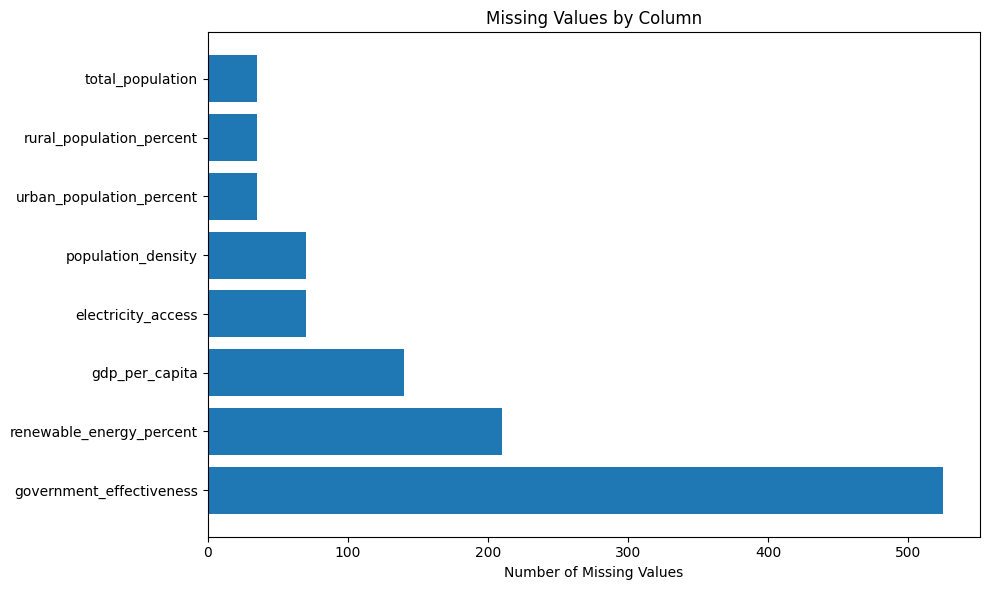


Total missing values: 1120


In [270]:
# Visualize missing data patterns
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.barh(missing_data.index, missing_data.values)
plt.xlabel('Number of Missing Values')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

In [271]:
# Create a copy for cleaning
df_clean = df.copy()

# Sort by country and year for proper time-series handling
df_clean = df_clean.sort_values(['country', 'year']).reset_index(drop=True)

print("Data sorted by country and year")
print(f"Shape: {df_clean.shape}")

Data sorted by country and year
Shape: (7700, 11)


In [272]:
# If any missing values remain in target variable, drop those rows
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['electricity_access'])
final_rows = len(df_clean)

print(f"Rows before dropping missing targets: {initial_rows}")
print(f"Rows after dropping missing targets: {final_rows}")
print(f"Rows dropped: {initial_rows - final_rows}")

Rows before dropping missing targets: 7700
Rows after dropping missing targets: 7630
Rows dropped: 70


In [273]:
# Basic info
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7630 entries, 0 to 7699
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   7630 non-null   str    
 1   country_code              7630 non-null   str    
 2   year                      7630 non-null   int64  
 3   electricity_access        7630 non-null   float64
 4   gdp_per_capita            7525 non-null   float64
 5   urban_population_percent  7630 non-null   float64
 6   rural_population_percent  7630 non-null   float64
 7   population_density        7595 non-null   float64
 8   total_population          7630 non-null   float64
 9   renewable_energy_percent  7455 non-null   float64
 10  government_effectiveness  7140 non-null   float64
dtypes: float64(8), int64(1), str(2)
memory usage: 715.3 KB


In [274]:
def create_risk_category(electricity_access):
    """
    Classify countries into risk categories based on electricity access percentage
    """
    if pd.isna(electricity_access):
        return None
    elif electricity_access < 50:
        return 'Severe'
    elif electricity_access < 90:
        return 'Moderate'
    else:
        return 'Minimal'

# Apply function to create target variable
df_clean['risk_category'] = df_clean['electricity_access'].apply(create_risk_category)

# Check distribution
print("Risk Category Distribution:")
print(df_clean['risk_category'].value_counts())
print("\nPercentages:")
print(df_clean['risk_category'].value_counts(normalize=True).mul(100).round(2))

Risk Category Distribution:
risk_category
Minimal     4774
Severe      1549
Moderate    1307
Name: count, dtype: int64

Percentages:
risk_category
Minimal     62.57
Severe      20.30
Moderate    17.13
Name: proportion, dtype: float64


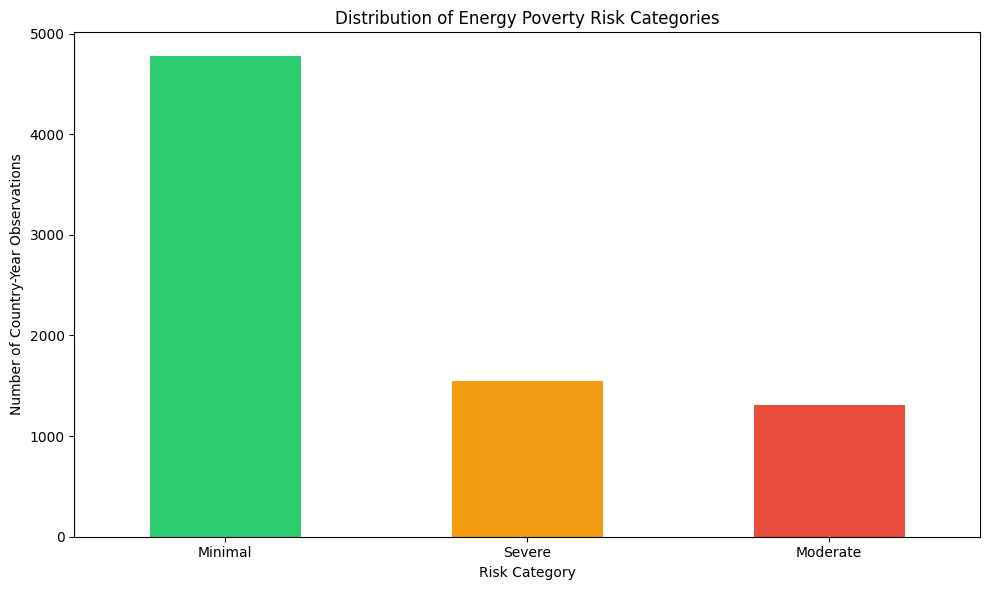

In [275]:
# Visualize risk category distribution
plt.figure(figsize=(10, 6))
df_clean['risk_category'].value_counts().plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Distribution of Energy Poverty Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Number of Country-Year Observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [276]:
# Year-over-year change in electricity access
df_clean['elec_access_change'] = df_clean.groupby('country_code')['electricity_access'].diff()

# GDP growth rate (percentage change)
df_clean['gdp_growth'] = df_clean.groupby('country_code')['gdp_per_capita'].pct_change() * 100

# Urbanization rate (year-over-year change in percentage points)
df_clean['urban_change'] = df_clean.groupby('country_code')['urban_population_percent'].diff()

print("Year-over-year change features created")
print("\nSample of new features:")
print(df_clean[['country', 'year', 'elec_access_change', 'gdp_growth', 'urban_change']].head(15))

Year-over-year change features created

Sample of new features:
        country  year  elec_access_change  gdp_growth  urban_change
0   Afghanistan  1990                 NaN         NaN           NaN
1   Afghanistan  1991                 0.0    0.000000      0.112626
2   Afghanistan  1992                 0.0    0.000000      0.111542
3   Afghanistan  1993                 0.0    0.000000      0.112265
4   Afghanistan  1994                 0.0    0.000000      0.114792
5   Afghanistan  1995                 0.0    0.000000      0.119125
6   Afghanistan  1996                 0.0    0.000000      0.125264
7   Afghanistan  1997                 0.0    0.000000      0.133208
8   Afghanistan  1998                 0.0    0.000000      0.142957
9   Afghanistan  1999                 0.0    0.000000      0.154512
10  Afghanistan  2000                 0.0    0.000000      0.167873
11  Afghanistan  2001                 4.9  -20.707691      0.183039
12  Afghanistan  2002                 4.8   29.01606

In [277]:
# Check for infinite values from pct_change
print("Checking for infinite values:")
print(f"GDP growth infinite values: {np.isinf(df_clean['gdp_growth']).sum()}")
print(f"Elec access change infinite values: {np.isinf(df_clean['elec_access_change']).sum()}")
print(f"Urban change infinite values: {np.isinf(df_clean['urban_change']).sum()}")

# Replace infinite values with NaN
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nInfinite values replaced with NaN")

Checking for infinite values:
GDP growth infinite values: 0
Elec access change infinite values: 0
Urban change infinite values: 0

Infinite values replaced with NaN


In [278]:
# Create lagged electricity access (previous year's value)
df_clean['lagged_electricity'] = df_clean.groupby('country_code')['electricity_access'].shift(1)

# Create lagged GDP per capita
df_clean['lagged_gdp'] = df_clean.groupby('country_code')['gdp_per_capita'].shift(1)

print("✅ Lagged features created")
print("\nSample of lagged features:")
print(df_clean[['country', 'year', 'electricity_access', 'lagged_electricity', 'gdp_per_capita', 'lagged_gdp']].head(10))

✅ Lagged features created

Sample of lagged features:
       country  year  electricity_access  lagged_electricity  gdp_per_capita  \
0  Afghanistan  1990                 4.4                 NaN      174.930991   
1  Afghanistan  1991                 4.4                 4.4      174.930991   
2  Afghanistan  1992                 4.4                 4.4      174.930991   
3  Afghanistan  1993                 4.4                 4.4      174.930991   
4  Afghanistan  1994                 4.4                 4.4      174.930991   
5  Afghanistan  1995                 4.4                 4.4      174.930991   
6  Afghanistan  1996                 4.4                 4.4      174.930991   
7  Afghanistan  1997                 4.4                 4.4      174.930991   
8  Afghanistan  1998                 4.4                 4.4      174.930991   
9  Afghanistan  1999                 4.4                 4.4      174.930991   

   lagged_gdp  
0         NaN  
1  174.930991  
2  174.930991  
3

In [279]:
# Display all columns
print("All columns in dataset:")
print(df_clean.columns.tolist())
print(f"\nTotal columns: {len(df_clean.columns)}")
print(f"Dataset shape: {df_clean.shape}")

All columns in dataset:
['country', 'country_code', 'year', 'electricity_access', 'gdp_per_capita', 'urban_population_percent', 'rural_population_percent', 'population_density', 'total_population', 'renewable_energy_percent', 'government_effectiveness', 'risk_category', 'elec_access_change', 'gdp_growth', 'urban_change', 'lagged_electricity', 'lagged_gdp']

Total columns: 17
Dataset shape: (7630, 17)


In [280]:
# Check missing values in new features
print("Missing values in engineered features:")
engineered_features = ['risk_category', 'elec_access_change', 'gdp_growth', 'urban_change', 'lagged_electricity', 'lagged_gdp']
for col in engineered_features:
    missing = df_clean[col].isnull().sum()
    missing_pct = (missing / len(df_clean)) * 100
    print(f"{col}: {missing} ({missing_pct:.2f}%)")

Missing values in engineered features:
risk_category: 0 (0.00%)
elec_access_change: 218 (2.86%)
gdp_growth: 320 (4.19%)
urban_change: 218 (2.86%)
lagged_electricity: 218 (2.86%)
lagged_gdp: 320 (4.19%)
